# CNN / ResNet UQ for a 2D Steady Heat Equation

This notebook studies a 2D source-to-solution map for the Poisson problem

$$
-\Delta u(x,y)=s(x,y),\qquad (x,y)\in[0,1)^2,
$$

with periodic boundary conditions and zero-mean source fields. The source field
is the model input, and the steady temperature field is the output.

We train a compact CNN and a ResNet baseline, then use **MC Dropout** to obtain
predictive uncertainty maps. The OOD set contains sharper source patterns with
higher spatial frequencies.

Primary references:

- He et al. (2016), *Deep Residual Learning for Image Recognition*
- Gal & Ghahramani (2016), *Dropout as a Bayesian Approximation*


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if not (repo_root / 'src').exists():
    repo_root = repo_root.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import MCDropoutWrapper
from deepuq.models import CNNRegressor2D, ResNetRegressor2D

torch.manual_seed(11)
np.random.seed(11)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


device: cuda


## Exact spectral dataset

Using a periodic Poisson solve keeps the dataset physically meaningful and
numerically exact. That lets us focus the notebook on model behavior and
uncertainty rather than on solver noise.


In [2]:
config = {
    'n_train': 192,
    'n_val': 48,
    'n_test': 48,
    'n_ood': 48,
    'grid_size': 32,
    'epochs': 120,
    'batch_size': 8,
    'lr': 2e-3,
}


def make_grid(n):
    x = torch.linspace(0.0, 1.0, n + 1)[:-1]
    X, Y = torch.meshgrid(x, x, indexing='ij')
    return X, Y

X, Y = make_grid(config['grid_size'])


def random_source(n_samples, *, ood=False):
    fields = []
    freq_cap = 3 if not ood else 6
    amp_scale = 1.0 if not ood else 1.8
    for _ in range(n_samples):
        field = torch.zeros_like(X)
        for kx in range(1, freq_cap + 1):
            for ky in range(1, freq_cap + 1):
                coeff = amp_scale * torch.randn(1).item() / (kx + ky)
                phase_x = 2 * math.pi * torch.rand(1).item()
                phase_y = 2 * math.pi * torch.rand(1).item()
                field = field + coeff * torch.sin(2 * math.pi * kx * X + phase_x) * torch.sin(2 * math.pi * ky * Y + phase_y)
        if ood:
            cx, cy = torch.rand(2).tolist()
            field = field + 1.5 * torch.exp(-80.0 * ((X - cx) ** 2 + (Y - cy) ** 2))
        field = field - field.mean()
        fields.append(field)
    return torch.stack(fields, dim=0)


def solve_periodic_poisson(source):
    source_hat = torch.fft.fftn(source, dim=(-2, -1))
    freqs = torch.fft.fftfreq(source.shape[-1], d=1.0 / source.shape[-1])
    kx, ky = torch.meshgrid(freqs, freqs, indexing='ij')
    denom = 4.0 * math.pi**2 * (kx**2 + ky**2)
    denom[0, 0] = 1.0
    solution_hat = source_hat / denom
    solution_hat[..., 0, 0] = 0.0
    return torch.fft.ifftn(solution_hat, dim=(-2, -1)).real


def build_dataset(n_samples, *, ood=False):
    src = random_source(n_samples, ood=ood)
    target = solve_periodic_poisson(src)
    return src.unsqueeze(1), target.unsqueeze(1)

train_x, train_y = build_dataset(config['n_train'])
val_x, val_y = build_dataset(config['n_val'])
test_x, test_y = build_dataset(config['n_test'])
ood_x, ood_y = build_dataset(config['n_ood'], ood=True)

train_loader = DataLoader(TensorDataset(train_x, train_y), batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(TensorDataset(val_x, val_y), batch_size=config['batch_size'])


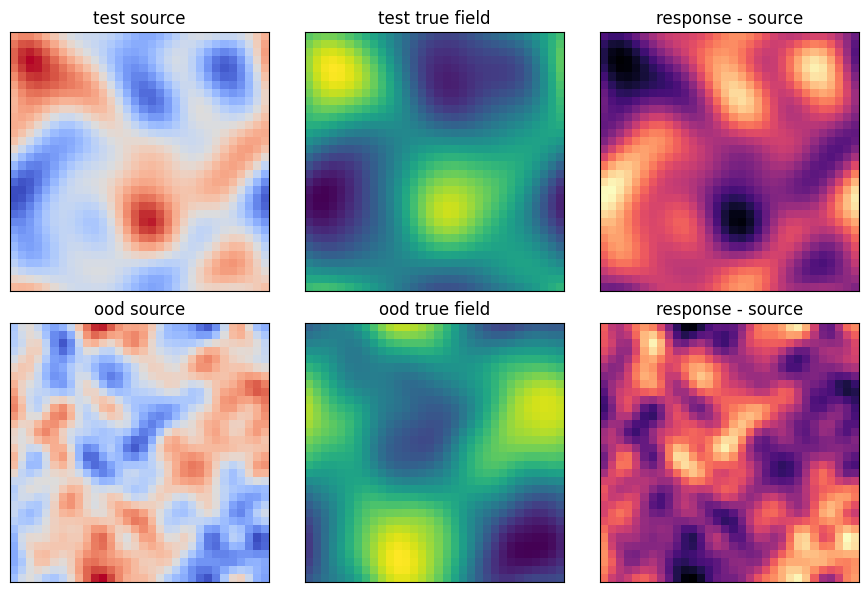

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row, (src, target, title) in enumerate([(test_x, test_y, 'test'), (ood_x, ood_y, 'ood')]):
    axes[row, 0].imshow(src[0, 0], cmap='coolwarm')
    axes[row, 0].set_title(f'{title} source')
    axes[row, 1].imshow(target[0, 0], cmap='viridis')
    axes[row, 1].set_title(f'{title} true field')
    axes[row, 2].imshow(target[0, 0] - src[0, 0], cmap='magma')
    axes[row, 2].set_title('response - source')
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


In [4]:
def fit_model(model):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-4)
    history = {'train': [], 'val': []}
    for _ in range(config['epochs']):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = torch.nn.functional.mse_loss(model(xb), yb)
            loss.backward()
            opt.step()
            train_loss += loss.item() * xb.size(0)
        history['train'].append(train_loss / len(train_loader.dataset))
        model.eval()
        val_loss = 0.0
        with torch.inference_mode():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += torch.nn.functional.mse_loss(model(xb), yb).item() * xb.size(0)
        history['val'].append(val_loss / len(val_loader.dataset))
    return model, history

cnn, cnn_hist = fit_model(CNNRegressor2D(dropout_p=0.1))
resnet, res_hist = fit_model(ResNetRegressor2D(dropout_p=0.1))


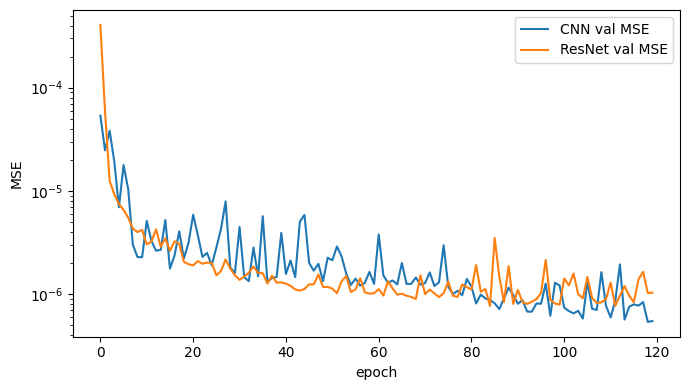

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(cnn_hist['val'], label='CNN val MSE')
plt.plot(res_hist['val'], label='ResNet val MSE')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
@torch.inference_mode()
def evaluate(model, x, y):
    pred = model(x.to(device)).cpu()
    rmse = torch.mean((pred - y) ** 2).sqrt().item()
    return pred, rmse

cnn_test_pred, cnn_test_rmse = evaluate(cnn, test_x, test_y)
res_test_pred, res_test_rmse = evaluate(resnet, test_x, test_y)
print({'cnn_test_rmse': cnn_test_rmse, 'resnet_test_rmse': res_test_rmse})

mc = MCDropoutWrapper(resnet, n_mc=20, apply_softmax=False)
res_test_uq = mc.predict_uq(test_x.to(device))
res_ood_uq = mc.predict_uq(ood_x.to(device))


{'cnn_test_rmse': 0.0007997571374289691, 'resnet_test_rmse': 0.001106524607166648}


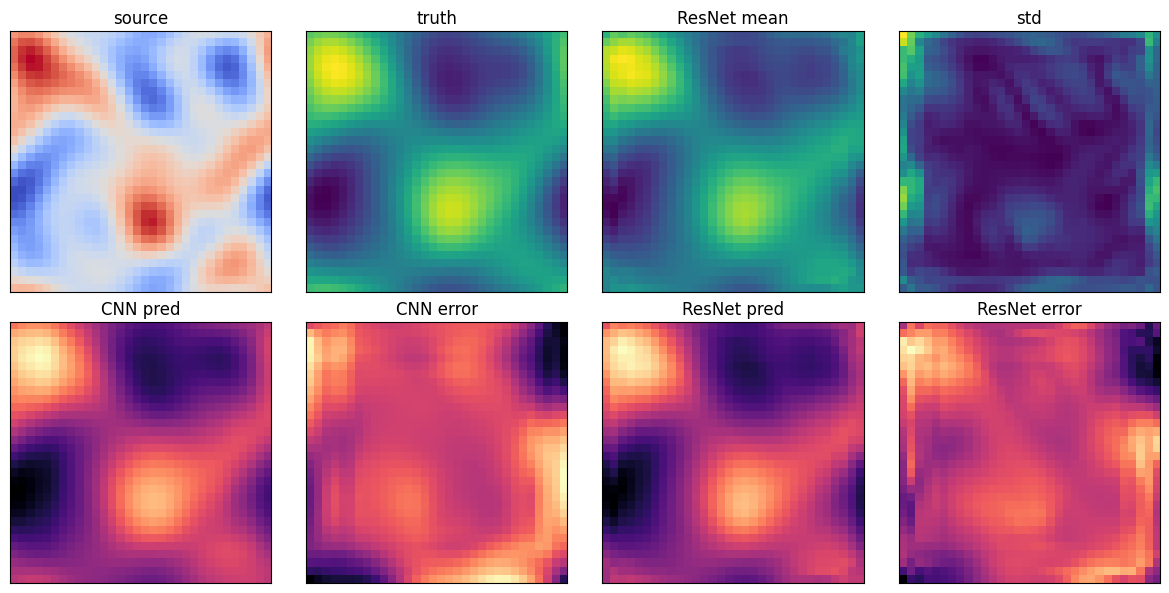

In [7]:
sample_idx = 0
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
items = [
    ('source', test_x[sample_idx, 0]),
    ('truth', test_y[sample_idx, 0]),
    ('ResNet mean', res_test_uq.mean.cpu()[sample_idx, 0]),
    ('std', res_test_uq.total_var.cpu()[sample_idx, 0].sqrt()),
]
for ax, (title, field) in zip(axes[0], items):
    ax.imshow(field, cmap='viridis' if title != 'source' else 'coolwarm')
    ax.set_title(title)
for ax, field in zip(axes[1], [cnn_test_pred[sample_idx, 0], cnn_test_pred[sample_idx, 0] - test_y[sample_idx, 0], res_test_pred[sample_idx, 0], res_test_uq.mean.cpu()[sample_idx, 0] - test_y[sample_idx, 0]]):
    ax.imshow(field, cmap='magma')
for ax, title in zip(axes[1], ['CNN pred', 'CNN error', 'ResNet pred', 'ResNet error']):
    ax.set_title(title)
for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()


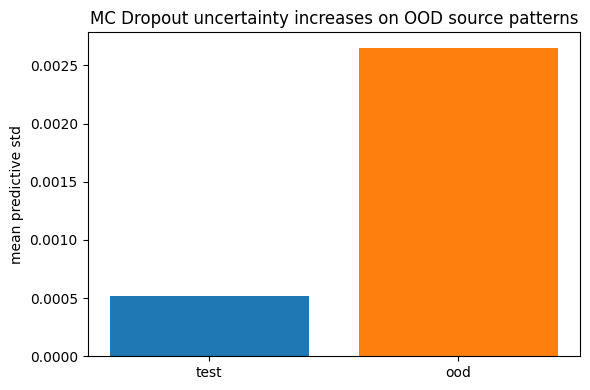

In [8]:
plt.figure(figsize=(6, 4))
plt.bar(
    ['test', 'ood'],
    [res_test_uq.total_var.cpu().sqrt().mean().item(), res_ood_uq.total_var.cpu().sqrt().mean().item()],
    color=['tab:blue', 'tab:orange'],
)
plt.ylabel('mean predictive std')
plt.title('MC Dropout uncertainty increases on OOD source patterns')
plt.tight_layout()
plt.show()
